# SVM (Support vector machine)

## Data Preprocessing Steps Overview

1. **Import Libraries** - Load required tools (pandas, numpy, sklearn)
2. **Load Dataset** - Read CSV file into memory
3. **Explore Data** - View first rows to understand structure
4. **Data Info** - Check data types and missing values
5. **Visualize Distribution** - Create boxplot to identify outliers
6. **Feature-Target Separation** - Split features (X) from target (y)
7. **Train-Test Split** - Divide data into 80% training and 20% testing sets
8. **Model Training** - Train SVM classifier on training data
9. **Evaluation** - Calculate accuracy on test data

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("customer_churn_dataset.csv")

In [4]:
data.head()

,Customer_ID,Age,Gender,Region,Monthly_Income,Subscription_Length_Months,Monthly_Bill,Support_Tickets,Internet_Usage_GB,Contract_Type,Payment_Method,Has_Multiple_Services,Last_Login_Days_Ago,Satisfaction_Score,Churn
0,CUST1000,50,Female,Chennai,84886,58,966,6,360,Monthly,Debit Card,Yes,11,8,1
1,CUST1001,57,Male,Bangalore,90263,24,630,5,338,Monthly,UPI,Yes,2,8,1
2,CUST1002,51,Male,Bangalore,97969,60,2824,0,489,Yearly,UPI,No,26,6,1
3,CUST1003,46,Female,Mumbai,55658,42,2547,3,219,Yearly,UPI,Yes,30,3,1
4,CUST1004,24,Male,Hyderabad,99092,51,1146,4,196,Monthly,Credit Card,Yes,18,4,1


In [5]:
 
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Customer_ID                 5000 non-null   object
 1   Age                         5000 non-null   int64 
 2   Gender                      5000 non-null   object
 3   Region                      5000 non-null   object
 4   Monthly_Income              5000 non-null   int64 
 5   Subscription_Length_Months  5000 non-null   int64 
 6   Monthly_Bill                5000 non-null   int64 
 7   Support_Tickets             5000 non-null   int64 
 8   Internet_Usage_GB           5000 non-null   int64 
 9   Contract_Type               5000 non-null   object
 10  Payment_Method              5000 non-null   object
 11  Has_Multiple_Services       5000 non-null   object
 12  Last_Login_Days_Ago         5000 non-null   int64 
 13  Satisfaction_Score          5000 non-null   int6

In [6]:
data = data.dropna()
print(f"Data shape after removing missing values: {data.shape}")

Data shape after removing missing values: (5000, 15)


<Axes: >

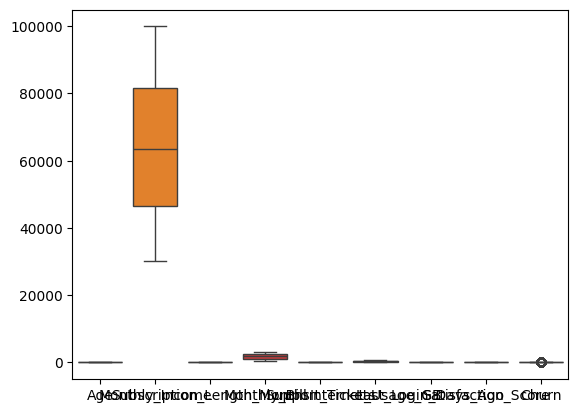

In [7]:
import seaborn as sns
sns.boxplot(data=data)

In [8]:

data_numeric = data.select_dtypes(include=['int64', 'float64']).copy()
print(f"Columns kept for modeling: {data_numeric.columns.tolist()}")
x = data_numeric.drop("Churn", axis=1) 
y = data_numeric["Churn"] 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"Training set size: {x_train.shape[0]}, Test set size: {x_test.shape[0]}")

Columns kept for modeling: ['Age', 'Monthly_Income', 'Subscription_Length_Months', 'Monthly_Bill', 'Support_Tickets', 'Internet_Usage_GB', 'Last_Login_Days_Ago', 'Satisfaction_Score', 'Churn']
Training set size: 4000, Test set size: 1000


In [9]:
w=2
x=3
b=4
y=w*x+b
print(y)
if(y>=0):
    print("class 1")
else:
    print("class 0")

10
class 1


In [12]:
 

from sklearn.metrics import accuracy_score
from sklearn.svm import SVC

 

svm_classifier = SVC(kernel="rbf", C=1.0, gamma="scale",degree=3,coef0=0.0 ,probability=False)

 
svm_classifier.fit(x_train, y_train)

 
y_pred = svm_classifier.predict(x_test)

 
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")   

Model Accuracy: 0.8850
